# دفتر اختبار استراتيجيات تداول العملات الرقمية باستخدام Backtesting.py

تم العودة لاستخدام مكتبة **backtesting.py** لسهولة استخدامها ووضوح نتائجها، مع الحفاظ على:
- مؤشر **FollowLine (FLI)** المخصص لكشف الانفجار السعري والهبوط.
- استراتيجيات الدخول والخروج بناءً على تغير لون الخط.

| المكتبة | الاستخدام |
|---|---|
| **ccxt** | جلب بيانات الشموع (OHLCV) من منصات التداول |
| **TA-Lib** | حساب مؤشرات بولينجر باند و ATR |
| **backtesting.py** | تنفيذ الاختبار الخلفي ورسم النتائج |
| **pandas / numpy** | معالجة البيانات وبناء مؤشر FollowLine |

## 1. تثبيت المكتبات

ملاحظة: تثبيت `TA-Lib` يتطلب أولاً تثبيت مكتبة C الأساسية على النظام.

In [2]:
import ccxt
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from backtesting.lib import crossover,cross
from backtesting import Backtest, Strategy

pd.set_option('display.max_columns', None)
%matplotlib inline

## 2. جلب البيانات التاريخية

**نطاق الإطار الزمني:** 5 دقائق إلى 30 دقيقة فأكثر (نستخدم 15 دقيقة افتراضيًا).

In [3]:
def fetch_ohlcv(symbol='BTC/USDT', timeframe='15m', limit=1500, exchange_id='binance'):
    exchange_class = getattr(ccxt, exchange_id)
    exchange = exchange_class({'enableRateLimit': True})
    raw = exchange.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    
    # backtesting.py تتطلب أسماء أعمدة معينة وحروف كبيرة (Capitalized)
    df = pd.DataFrame(raw, columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df['Date'] = pd.to_datetime(df['Date'], unit='ms')
    df.set_index('Date', inplace=True)
    return df

# إطار زمني 15 دقيقة (ضمن النطاق 5م - 30م+)
SYMBOL = 'LA/USDT'
TIMEFRAME = '15m'
data = fetch_ohlcv(symbol=SYMBOL, timeframe=TIMEFRAME, limit=1500, exchange_id='binance')
print(f'تم جلب {len(data)} شمعة لـ {SYMBOL} على إطار {TIMEFRAME}')
data.tail()

تم جلب 1000 شمعة لـ LA/USDT على إطار 15m


,Open,High,Low,Close,Volume
Date,,,,,
2026-07-29 17:30:00,0.0548,0.0555,0.0548,0.0553,522032.7
2026-07-29 17:45:00,0.0553,0.0554,0.0547,0.0549,440750.5
2026-07-29 18:00:00,0.0549,0.0555,0.0546,0.0546,1031330.9
2026-07-29 18:15:00,0.0546,0.0547,0.0537,0.0539,717531.7
2026-07-29 18:30:00,0.0541,0.0541,0.0531,0.0534,603594.3


## 3. بناء مؤشر FollowLine (FLI)

بناءً على وصفك، مؤشر **FollowLine** هو مؤشر اتباع للاتجاه (Trend Following):
- **التفعيل:** يتغير للأزرق (صعودي) عند إغلاق السعر فوق الحد العلوي لبولينجر باند، وللأحمر (هبوطي) عند الإغلاق تحت الحد السفلي.
- **موضع الخط:**
  - في الاتجاه الصعودي: يوضع عند أدنى سعر (Low) للشمعة.
  - في الاتجاه الهبوطي: يوضع عند أعلى سعر (High) للشمعة.
- **فلتر ATR:** يمكن دفع الخط لمسافة أبعد باستخدام ATR (يُطرح في الصعود، ويُجمع في الهبوط) لتقليل الإشارات الكاذبة.
- **التتبع (Trailing):** يتتبع الخط السعر ولا يتراجع عكس الاتجاه.
- **الإلغاء:** يُلغى الخط (يعود لحالة عدم اتجاه) إذا أغلق السعر عكسه.

In [4]:
def add_follow_line(df, bb_period=20, bb_dev=2.0, atr_period=14, use_atr=True, atr_mult=1.0):
    """
    حساب مؤشر FollowLine وإضافته للبيانات.
    """
    close = df['Close'].to_numpy(dtype=float)
    high = df['High'].to_numpy(dtype=float)
    low = df['Low'].to_numpy(dtype=float)
    
    upper, mid, lower = talib.BBANDS(close, timeperiod=bb_period, nbdevup=bb_dev, nbdevdn=bb_dev)
    atr = talib.ATR(high, low, close, timeperiod=atr_period)
    
    fl = np.full_like(close, np.nan)
    trend = np.zeros(len(close), dtype=int)  # 1 للأزرق (صعود), -1 للأحمر (هبوط)
    
    curr_trend = 0
    curr_fl = np.nan
    
    for i in range(len(close)):
        if np.isnan(upper[i]) or np.isnan(atr[i]):
            continue
        
        # تفعيل الترند عند اختراق بولينجر باند
        if curr_trend == 0:
            if close[i] > upper[i]:
                curr_trend = 1
            elif close[i] < lower[i]:
                curr_trend = -1
                
        if curr_trend == 1:
            level = low[i] - (atr[i] * atr_mult if use_atr else 0)
            curr_fl = max(curr_fl, level) if not np.isnan(curr_fl) else level
            # إلغاء الترند إذا أغلق السعر تحت الخط
            if close[i] < curr_fl:
                curr_trend = 0
                curr_fl = np.nan
                
        elif curr_trend == -1:
            level = high[i] + (atr[i] * atr_mult if use_atr else 0)
            curr_fl = min(curr_fl, level) if not np.isnan(curr_fl) else level
            # إلغاء الترند إذا أغلق السعر فوق الخط
            if close[i] > curr_fl:
                curr_trend = 0
                curr_fl = np.nan
                
        trend[i] = curr_trend
        fl[i] = curr_fl
        
    df['FollowLine'] = fl
    df['FollowTrend'] = trend
    return df

# تطبيق المؤشر على البيانات
data = add_follow_line(data, use_atr=False, atr_mult=1.0)
print('تم حساب مؤشر FollowLine بنجاح')
data.tail()

تم حساب مؤشر FollowLine بنجاح


,Open,High,Low,Close,Volume,FollowLine,FollowTrend
Date,,,,,,,
2026-07-29 17:30:00,0.0548,0.0555,0.0548,0.0553,522032.7,NaN,0
2026-07-29 17:45:00,0.0553,0.0554,0.0547,0.0549,440750.5,NaN,0
2026-07-29 18:00:00,0.0549,0.0555,0.0546,0.0546,1031330.9,NaN,0
2026-07-29 18:15:00,0.0546,0.0547,0.0537,0.0539,717531.7,NaN,0
2026-07-29 18:30:00,0.0541,0.0541,0.0531,0.0534,603594.3,NaN,0


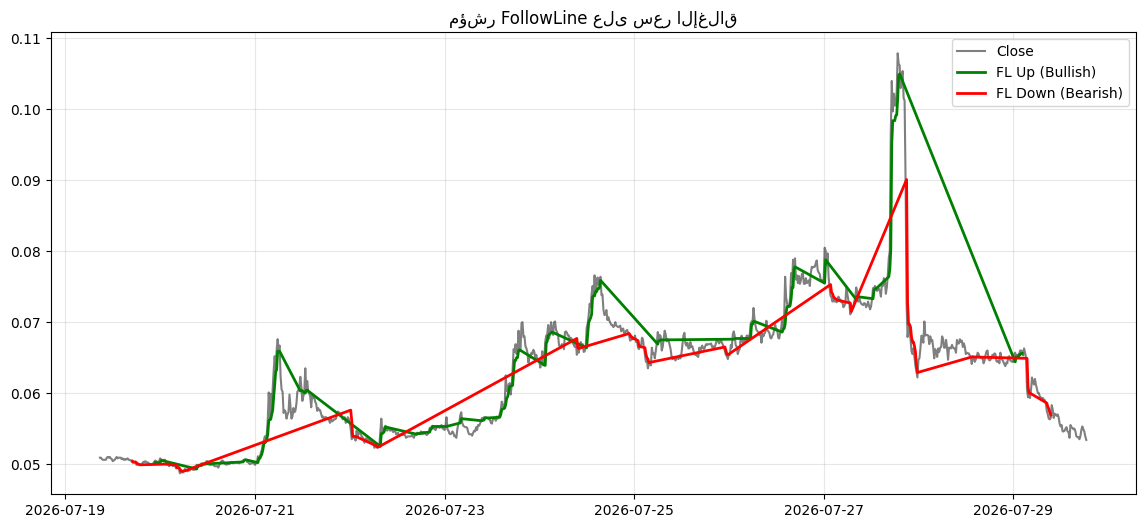

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(data.index, data['Close'], label='Close', color='black', alpha=0.5)

# رسم خطوط FollowLine بألوانها
up_trend = data[data['FollowTrend'] == 1]
down_trend = data[data['FollowTrend'] == -1]

ax.plot(up_trend.index, up_trend['FollowLine'], label='FL Up (Bullish)', color='green', lw=2)
ax.plot(down_trend.index, down_trend['FollowLine'], label='FL Down (Bearish)', color='red', lw=2)

ax.set_title('مؤشر FollowLine على سعر الإغلاق')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 4. تعريف الاستراتيجيه لـ Backtesting.py

In [6]:
class MomStrategy(Strategy):
    def init(self):
        # 1. تغليف المؤشر باستخدام self.I ليتمكن backtesting.py من تتبعه
        self.mom = self.I(talib.MOM, self.data.Close, timeperiod=10)
        
        # 2. تحديد النطاقات
        self.up_zone = 0.00639
        self.middle_zone = 0.00001  # يعمل كخط الصفر أو نقطة الفصل
        self.down_zone = -0.006660

    def next(self):
        mom_now = self.mom[-1]

        # --- منطقة الانفجار الصعودي (دخول شراء) ---
        # ندخل فقط إذا تجاوز up_zone (زخم قوي يمنع التذبذب)
        if mom_now > self.up_zone:
            if not self.position:
                self.buy()  # فتح صفقة شراء (Long)
                
        # --- منطقة الانفجار الهبوطي (دخول بيع) ---
        # ندخل فقط إذا نزل تحت down_zone (زخم هبوطي قوي)
        elif mom_now < self.down_zone:
            if not self.position:
                self.sell()  # فتح صفقة بيع (Short)
                
        # --- منطقة ضعف الزخم (إغلاق الصفقات) ---
        # إذا كنا في صفقة وضعف الزخم وعاد للمنطقة العرضية
        else:
            # إغلاق الشراء إذا هبط المؤشر وتقاطع مع middle_zone
            if self.position.is_long and mom_now < self.middle_zone:
                self.position.close()
                
            # إغلاق البيع إذا ارتفع المؤشر وتقاطع مع middle_zone
            elif self.position.is_short and mom_now > self.middle_zone:
                self.position.close()

In [7]:
import talib
import numpy as np
import pandas as pd
from backtesting import Strategy, Backtest

def compute_all_indicators(df, bb_period=20, bb_dev=2.0, atr_period=14, atr_mult=1.0, mom_period=10):
    """دالة موحدة لحساب مؤشر FLI و MOM وإضافتهما للبيانات"""
    close = df['Close'].to_numpy(dtype=float)
    high = df['High'].to_numpy(dtype=float)
    low = df['Low'].to_numpy(dtype=float)

    # 1. حساب Bollinger Bands و ATR لـ FLI
    upper, mid, lower = talib.BBANDS(close, timeperiod=bb_period, nbdevup=bb_dev, nbdevdn=bb_dev)
    atr = talib.ATR(high, low, close, timeperiod=atr_period)

    # 2. حساب مؤشر MOM
    df['MOM'] = talib.MOM(close, timeperiod=mom_period)

    # 3. حساب خط المتابعة FollowLine (FLI)
    fl = np.full_like(close, np.nan)
    trend = np.zeros(len(close), dtype=int)  # 1 للأزرق (صعود), -1 للأحمر (هبوط)
    
    curr_trend = 0
    curr_fl = np.nan
    
    for i in range(len(close)):
        if np.isnan(upper[i]) or np.isnan(atr[i]):
            continue
        
        if curr_trend == 0:
            if close[i] > upper[i]: curr_trend = 1
            elif close[i] < lower[i]: curr_trend = -1
            
        if curr_trend == 1:
            level = low[i] - (atr[i] * atr_mult)
            curr_fl = max(curr_fl, level) if not np.isnan(curr_fl) else level
            if close[i] < curr_fl:
                curr_trend = 0
                curr_fl = np.nan
                
        elif curr_trend == -1:
            level = high[i] + (atr[i] * atr_mult)
            curr_fl = min(curr_fl, level) if not np.isnan(curr_fl) else level
            if close[i] > curr_fl:
                curr_trend = 0
                curr_fl = np.nan
                
        trend[i] = curr_trend
        fl[i] = curr_fl
        
    df['FollowLine'] = fl
    df['FollowTrend'] = trend
    return df

In [8]:
class CombinedMomFliStrategy(Strategy):
    def init(self):
        # تسجيل المؤشرات ليتمكن backtesting.py من قراءتها كسلاسل زمنية
        self.mom = self.I(lambda x: x, self.data.MOM, name='MOM')
        self.fli_trend = self.I(lambda x: x, self.data.FollowTrend, name='FollowTrend')
        self.fli_line = self.I(lambda x: x, self.data.FollowLine, name='FollowLine')

        # إعدادات MomStrategy
        self.up_zone = 0.00639
        self.middle_zone = 0.00001
        self.down_zone = -0.006660

    def next(self):
        if len(self.fli_trend) < 2:
            return

        mom_now = self.mom[-1]
        fli_trend_now = self.fli_trend[-1]
        fli_trend_prev = self.fli_trend[-2]

        # استخراج إشارات MOM (لها الأولوية في الاستباق)
        mom_buy = mom_now > self.up_zone
        mom_sell = mom_now < self.down_zone
        mom_exit_long = mom_now < self.middle_zone
        mom_exit_short = mom_now > self.middle_zone

        # استخراج إشارات FLI
        fli_buy = (fli_trend_now == 1 and fli_trend_prev != 1)
        fli_sell = (fli_trend_now == -1 and fli_trend_prev != -1)
        fli_exit_long = (fli_trend_now != 1 and fli_trend_prev == 1)
        fli_exit_short = (fli_trend_now != -1 and fli_trend_prev == -1)

        # --- 1. منطق الدخول (شراء) ---
        # إذا أعطى MOM إشارة شراء، أو أعطى FLI إشارة شراء (مع غياب إشارة البيع من MOM)
        if mom_buy or (fli_buy and not mom_sell):
            if self.position.is_short:
                self.position.close()  # إغلاق الشورت فوراً
            if not self.position.is_long:
                self.buy()  # فتح لونغ

        # --- 2. منطق الدخول (بيع) ---
        # إذا أعطى MOM إشارة بيع، أو أعطى FLI إشارة بيع (مع غياب إشارة الشراء من MOM)
        elif mom_sell or (fli_sell and not mom_buy):
            if self.position.is_long:
                self.position.close()  # إغلاق اللونغ فوراً
            if not self.position.is_short:
                self.sell()  # فتح شورت

        # --- 3. منطق الخروج (إغلاق الصفقة) ---
        # إذا لم تكن هناك إشارات دخول جديدة، نتحقق من إشارات الخروج من أي استراتيجية
        else:
            # الخروج من صفقة الشراء
            if self.position.is_long:
                # الخروج إذا قال MOM بضعف الزخم، أو إذا انكسر خط FLI
                if mom_exit_long or fli_exit_long:
                    self.position.close()

            # الخروج من صفقة البيع
            elif self.position.is_short:
                # الخروج إذا قال MOM بضعف الزخم الهبوطي، أو إذا انكسر خط FLI
                if mom_exit_short or fli_exit_short:
                    self.position.close()

## 5. تشغيل الاختبارات الخلفية

نُشغّل كل استراتيجية على نفس البيانات ونقارن النتائج.

In [9]:
bt_mom = Backtest(data,MomStrategy,cash=100,commission=0.0001)
status_mom = bt_mom.run()
print('Mom Stratgy')
print(status_mom)
bt_mom.plot()

Backtest.run:   0%|          | 0/989 [00:00<?, ?bar/s]

Mom Stratgy
Start                     2026-07-19 08:45:00
End                       2026-07-29 18:30:00
Duration                     10 days 09:45:00
Exposure Time [%]                        12.6
Equity Final [$]                    129.00869
Equity Peak [$]                     139.06265
Commissions [$]                       0.18991
Return [%]                           29.00869
Buy & Hold Return [%]                 4.70588
Return (Ann.) [%]                468214.87094
Volatility (Ann.) [%]            3775054.8023
CAGR [%]                         758421.75607
Sharpe Ratio                          0.12403
Sortino Ratio                     13464.10205
Calmar Ratio                      29786.39583
Alpha [%]                            28.77413
Beta                                  0.04984
Max. Drawdown [%]                   -15.71908
Avg. Drawdown [%]                    -6.07431
Max. Drawdown Duration        6 days 13:00:00
Avg. Drawdown Duration        1 days 05:15:00
# Trades              

GridPlot(id='p1379', ...)

In [10]:
# إعداد البيانات (تأكد من أن البيانات تحتوي على الأعمدة المطلوبة)
data = compute_all_indicators(data)

# تشغيل الاختبار الخلفي
# ملاحظة: exclusive_orders=True تضمن إغلاق أي صفقة مفتوحة فور فتح صفقة عكسية
bt = Backtest(data, CombinedMomFliStrategy, cash=100, commission=0.0001, exclusive_orders=True)
stats = bt.run()

print(stats)
bt.plot()

Backtest.run:   0%|          | 0/966 [00:00<?, ?bar/s]

Start                     2026-07-19 08:45:00
End                       2026-07-29 18:30:00
Duration                     10 days 09:45:00
Exposure Time [%]                        38.0
Equity Final [$]                    157.92538
Equity Peak [$]                     181.23705
Commissions [$]                       0.85572
Return [%]                           57.92538
Buy & Hold Return [%]                  6.3745
Return (Ann.) [%]             412098837.59504
Volatility (Ann.) [%]       56472330872.54132
CAGR [%]                      913517063.88732
Sharpe Ratio                           0.0073
Sortino Ratio                   6410345.91105
Calmar Ratio                   21545374.95987
Alpha [%]                            56.24558
Beta                                  0.26352
Max. Drawdown [%]                   -19.12702
Avg. Drawdown [%]                    -4.49964
Max. Drawdown Duration        6 days 11:30:00
Avg. Drawdown Duration        0 days 17:51:00
# Trades                          

GridPlot(id='p1883', ...)

In [11]:
import talib
import numpy as np
import pandas as pd
from backtesting import Strategy, Backtest

# ==========================================
# 1. Hull MA Helper Functions (Matching Pine Script)
# ==========================================

def compute_hma(series, length):
    half_length = int(length / 2)
    sqrt_length = int(np.round(np.sqrt(length)))
    wma_half = talib.WMA(series, half_length)
    wma_full = talib.WMA(series, length)
    return talib.WMA(2 * wma_half - wma_full, sqrt_length)

def compute_ehma(series, length):
    half_length = int(length / 2)
    sqrt_length = int(np.round(np.sqrt(length)))
    ema_half = talib.EMA(series, half_length)
    ema_full = talib.EMA(series, length)
    return talib.EMA(2 * ema_half - ema_full, sqrt_length)

def compute_thma(series, length):
    third_length = int(length / 3)
    half_length = int(length / 2)
    wma_third = talib.WMA(series, third_length)
    wma_half = talib.WMA(series, half_length)
    wma_full = talib.WMA(series, length)
    return talib.WMA(3 * wma_third - wma_half - wma_full, length)

# ==========================================
# 2. Unified Indicator Calculation Function
# ==========================================

def compute_all_indicators(df, bb_period=20, bb_dev=2.0, atr_period=14, atr_mult=1.0, 
                           mom_period=10, hull_mode='Hma', hull_length=55, hull_mult=1.0):
    """
    دالة موحدة لحساب مؤشرات FLI, MOM, و Hull MA وإضافتها للبيانات
    """
    close = df['Close'].to_numpy(dtype=float)
    high = df['High'].to_numpy(dtype=float)
    low = df['Low'].to_numpy(dtype=float)

    # 1. حساب Bollinger Bands و ATR لـ FLI
    upper, mid, lower = talib.BBANDS(close, timeperiod=bb_period, nbdevup=bb_dev, nbdevdn=bb_dev)
    atr = talib.ATR(high, low, close, timeperiod=atr_period)

    # 2. حساب مؤشر MOM
    df['MOM'] = talib.MOM(close, timeperiod=mom_period)

    # 3. حساب خط المتابعة FollowLine (FLI)
    fl = np.full_like(close, np.nan)
    trend = np.zeros(len(close), dtype=int)  # 1 للأخضر/الأزرق (صعود), -1 للأحمر (هبوط)

    curr_trend = 0
    curr_fl = np.nan

    for i in range(len(close)):
        if np.isnan(upper[i]) or np.isnan(atr[i]):
            continue

        if curr_trend == 0:
            if close[i] > upper[i]: 
                curr_trend = 1
            elif close[i] < lower[i]: 
                curr_trend = -1

        if curr_trend == 1:
            level = low[i] - (atr[i] * atr_mult)
            curr_fl = max(curr_fl, level) if not np.isnan(curr_fl) else level
            if close[i] < curr_fl:
                curr_trend = 0
                curr_fl = np.nan

        elif curr_trend == -1:
            level = high[i] + (atr[i] * atr_mult)
            curr_fl = min(curr_fl, level) if not np.isnan(curr_fl) else level
            if close[i] > curr_fl:
                curr_trend = 0
                curr_fl = np.nan

        trend[i] = curr_trend
        fl[i] = curr_fl

    df['FollowLine'] = fl
    df['FollowTrend'] = trend

    # 4. حساب مؤشر Hull MA بناءً على الوضع المختار
    adj_length = int(hull_length * hull_mult)
    if hull_mode == 'Hma':
        df['HullMA'] = compute_hma(close, adj_length)
    elif hull_mode == 'Ehma':
        df['HullMA'] = compute_ehma(close, adj_length)
    elif hull_mode == 'Thma':
        df['HullMA'] = compute_thma(close, adj_length)
    else:
        df['HullMA'] = np.nan

    # إزاحة المؤشر بمقدار 2 شمعة لمطابقة منطق Pine Script (SHULL)
    df['HullMA_Shifted'] = df['HullMA'].shift(2)

    return df

# ==========================================
# 3. Updated Combined Strategy with Hull MA
# ==========================================

class CombinedMomFliHullStrategy(Strategy):
    def init(self):
        # تسجيل المؤشرات ليتمكن backtesting.py من قراءتها كسلاسل زمنية
        self.mom = self.I(lambda x: x, self.data.MOM, name='MOM')
        self.fli_trend = self.I(lambda x: x, self.data.FollowTrend, name='FollowTrend')
        self.fli_line = self.I(lambda x: x, self.data.FollowLine, name='FollowLine')
        self.hull_ma = self.I(lambda x: x, self.data.HullMA, name='HullMA')
        self.hull_ma_shifted = self.I(lambda x: x, self.data.HullMA_Shifted, name='HullMA_Shifted')

        # إعدادات MomStrategy
        self.up_zone = 0.00639
        self.middle_zone = 0.00001
        self.down_zone = -0.006660

    def next(self):
        # التأكد من توفر بيانات كافية للحساب
        if len(self.fli_trend) < 3:
            return

        mom_now = self.mom[-1]
        fli_trend_now = self.fli_trend[-1]
        fli_trend_prev = self.fli_trend[-2]
        
        hull_now = self.hull_ma[-1]
        hull_shifted = self.hull_ma_shifted[-1]
        hull_prev = self.hull_ma[-2]
        hull_shifted_prev = self.hull_ma_shifted[-2]
        
        # تحديد اتجاه Hull MA (1 للصعود، -1 للهبوط) بناءً على MHULL > SHULL
        hull_trend = 1 if hull_now > hull_shifted else -1
        hull_trend_prev = 1 if hull_prev > hull_shifted_prev else -1

        # --- استخراج إشارات MOM ---
        mom_buy = mom_now > self.up_zone
        mom_sell = mom_now < self.down_zone
        mom_exit_long = mom_now < self.middle_zone
        mom_exit_short = mom_now > self.middle_zone

        # --- استخراج إشارات FLI ---
        fli_buy = (fli_trend_now == 1 and fli_trend_prev != 1)
        fli_sell = (fli_trend_now == -1 and fli_trend_prev != -1)
        fli_exit_long = (fli_trend_now != 1 and fli_trend_prev == 1)
        fli_exit_short = (fli_trend_now != -1 and fli_trend_prev == -1)

        # --- استخراج إشارات Hull MA (تقاطع) ---
        hull_buy = (hull_trend == 1 and hull_trend_prev != 1)
        hull_sell = (hull_trend == -1 and hull_trend_prev != -1)
        hull_exit_long = (hull_trend == -1 and hull_trend_prev == 1)
        hull_exit_short = (hull_trend == 1 and hull_trend_prev == -1)

        # --- 1. منطق الدخول (شراء Long) ---
        # الدخول إذا أعطى MOM أو FLI أو Hull إشارة شراء، مع التأكد من أن اتجاه Hull العام صعودي (فلتر)
        if (mom_buy or (fli_buy and not mom_sell) or hull_buy) and hull_trend == 1:
            if self.position.is_short:
                self.position.close()  # إغلاق الشورت فوراً
            if not self.position.is_long:
                self.buy()  # فتح لونغ

        # --- 2. منطق الدخول (بيع Short) ---
        # الدخول إذا أعطى MOM أو FLI أو Hull إشارة بيع، مع التأكد من أن اتجاه Hull العام هبوطي (فلتر)
        elif (mom_sell or (fli_sell and not mom_buy) or hull_sell) and hull_trend == -1:
            if self.position.is_long:
                self.position.close()  # إغلاق اللونغ فوراً
            if not self.position.is_short:
                self.sell()  # فتح شورت

        # --- 3. منطق الخروج (إغلاق الصفقة) ---
        # إذا لم تكن هناك إشارات دخول جديدة، نتحقق من إشارات الخروج من أي استراتيجية
        else:
            if self.position.is_long:
                if mom_exit_long or fli_exit_long or hull_exit_long:
                    self.position.close()
            elif self.position.is_short:
                if mom_exit_short or fli_exit_short or hull_exit_short:
                    self.position.close()

# ==========================================
# 4. Example Usage (How to run it)
# ==========================================
if __name__ == "__main__":
    # 1. افترض أن 'data' هو DataFrame الخاص بك الذي تم جلبه مسبقاً
    # data = fetch_ohlcv(symbol='BTC/USDT', timeframe='15m', limit=1500)
    
    # 2. حساب جميع المؤشرات (يمكنك تغيير hull_mode إلى 'Ehma' أو 'Thma' حسب رغبتك)
    data = compute_all_indicators(data, hull_mode='Hma', hull_length=55, hull_mult=1.0)
    
    # 3. تشغيل الاختبار الخلفي
    # ملاحظة: exclusive_orders=True تضمن إغلاق أي صفقة مفتوحة فور فتح صفقة عكسية
    bt = Backtest(data, CombinedMomFliHullStrategy, cash=100, commission=0.0001, exclusive_orders=True)
    
    # 4. عرض النتائج والرسم البياني
    stats = bt.run()
    print(stats)
    bt.plot()

Backtest.run:   0%|          | 0/937 [00:00<?, ?bar/s]

Start                     2026-07-19 08:45:00
End                       2026-07-29 18:30:00
Duration                     10 days 09:45:00
Exposure Time [%]                        56.5
Equity Final [$]                     94.76401
Equity Peak [$]                     130.16063
Commissions [$]                       1.40619
Return [%]                           -5.23599
Buy & Hold Return [%]                  5.5336
Return (Ann.) [%]                   -83.21245
Volatility (Ann.) [%]               179.83197
CAGR [%]                            -84.83762
Sharpe Ratio                         -0.46272
Sortino Ratio                        -0.66836
Calmar Ratio                         -2.37451
Alpha [%]                            -7.06416
Beta                                  0.33038
Max. Drawdown [%]                   -35.04409
Avg. Drawdown [%]                    -5.77915
Max. Drawdown Duration        8 days 12:45:00
Avg. Drawdown Duration        1 days 01:34:00
# Trades                          